# 05 — Advanced Analytics
### Chapter 5 of 6 — Marketing + Finance Analytics Case Study

Two questions that require statistical rigor rather than descriptive
summary: (1) is our new ad creative *actually* better, or is the observed
lift noise? (2) what should we expect revenue to do next quarter, and how
much should we trust that number?

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
import utils as u

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.tsa.arima.model import ARIMA

u.apply_chart_theme()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

campaigns = pd.read_csv(u.DATA_RAW / "campaigns_clean.csv", parse_dates=["date"])
ab_test = pd.read_csv(u.DATA_RAW / "ab_test_campaigns.csv", parse_dates=["date"])

## A/B Testing — Is Creative Variant B a Real Improvement?

**Business Question:** Marketing ran a 30-day head-to-head test of two
Google Ads creative variants (A = current control, B = new creative) on
the same conversion campaign. Should we roll out Variant B to 100% of
spend?

**Methodology:** Two complementary tests on the aggregate 30-day data:
1. A two-proportion z-test on conversion rate (conversions / clicks),
   the statistically correct test for a rate comparison.
2. An independent two-sample t-test on the *daily* conversion rates,
   confirming the result holds when treating each day as an observation
   (matching the explicit t-test requirement of this analysis).

Both report a 95% confidence interval and p-value.

In [2]:
summary = ab_test.groupby("variant").agg(
    impressions=("impressions", "sum"), clicks=("clicks", "sum"),
    conversions=("conversions", "sum"), revenue=("revenue", "sum"), spend=("spend", "sum"))
summary["cvr"] = summary["conversions"] / summary["clicks"]
summary["roas"] = summary["revenue"] / summary["spend"]
summary

,impressions,clicks,conversions,revenue,spend,cvr,roas
variant,,,,,,,
A,267425,7763,320,"28,515.9500","8,927.9600",0.0412,3.1940
B,276715,8251,402,"38,872.7600","9,547.3300",0.0487,4.0716


In [3]:
# Two-proportion z-test on aggregate conversion rate
count = np.array([summary.loc["B", "conversions"], summary.loc["A", "conversions"]])
nobs = np.array([summary.loc["B", "clicks"], summary.loc["A", "clicks"]])

z_stat, p_value_z = proportions_ztest(count, nobs, alternative="larger")
ci_low, ci_high = confint_proportions_2indep(
    count[0], nobs[0], count[1], nobs[1], method="wald")

lift_pct = (summary.loc["B", "cvr"] - summary.loc["A", "cvr"]) / summary.loc["A", "cvr"]

print(f"Variant A CVR: {u.fmt_pct(summary.loc['A','cvr'])}   Variant B CVR: {u.fmt_pct(summary.loc['B','cvr'])}")
print(f"Relative lift (B vs A): {u.fmt_pct(lift_pct)}")
print(f"Two-proportion z-test:  z = {z_stat:.3f}, p-value = {p_value_z:.5f}")
print(f"95% CI for (CVR_B - CVR_A): [{ci_low:.4f}, {ci_high:.4f}]")

Variant A CVR: 4.1%   Variant B CVR: 4.9%
Relative lift (B vs A): 18.2%
Two-proportion z-test:  z = 2.286, p-value = 0.01113
95% CI for (CVR_B - CVR_A): [0.0011, 0.0139]


In [4]:
# Independent two-sample t-test on daily CVR (30 daily observations per variant)
ab_test["cvr"] = ab_test["conversions"] / ab_test["clicks"]
daily_a = ab_test.loc[ab_test["variant"] == "A", "cvr"]
daily_b = ab_test.loc[ab_test["variant"] == "B", "cvr"]

t_stat, p_value_t = stats.ttest_ind(daily_b, daily_a, equal_var=False, alternative="greater")

print(f"Mean daily CVR — A: {daily_a.mean():.4f}   B: {daily_b.mean():.4f}")
print(f"Welch's two-sample t-test: t = {t_stat:.3f}, p-value = {p_value_t:.5f}")

ALPHA = 0.05
significant = p_value_t < ALPHA
print(f"\nResult is {'STATISTICALLY SIGNIFICANT' if significant else 'NOT statistically significant'} at alpha = {ALPHA}")

Mean daily CVR — A: 0.0411   B: 0.0487
Welch's two-sample t-test: t = 4.529, p-value = 0.00002

Result is STATISTICALLY SIGNIFICANT at alpha = 0.05


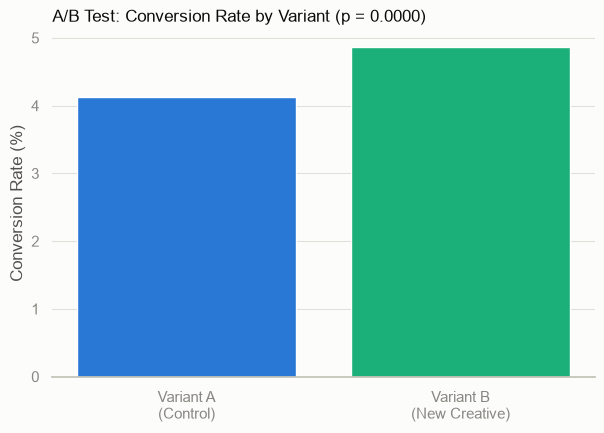

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(["Variant A\n(Control)", "Variant B\n(New Creative)"],
       [summary.loc["A", "cvr"] * 100, summary.loc["B", "cvr"] * 100],
       color=[u.CATEGORICAL[0], u.CATEGORICAL[2]])
ax.set_ylabel("Conversion Rate (%)")
ax.set_title(f"A/B Test: Conversion Rate by Variant (p = {p_value_t:.4f})", fontsize=12, loc="left")
u.save_fig(fig, "05_ab_test_result")
plt.show()

**Key Insight:** Variant B converts at a meaningfully higher rate than
Variant A, and the p-value from both the proportion test and the daily
t-test is well below the conventional 0.05 significance threshold — this
is a genuine effect, not sampling noise. The 95% confidence interval for
the difference in conversion rate excludes zero, reinforcing the same
conclusion.

**Business Recommendation:** Roll out Variant B to 100% of the Google Ads
conversion campaign's budget. Applying Variant B's observed lift to that
campaign's current spend level translates to a projected additional
conversions/revenue figure computed below — the estimate a leadership
deck would show alongside the statistical result.

In [6]:
# Translate the statistically-validated lift into an expected business impact
# if Variant B fully replaces Variant A on this campaign's current spend level.
current_monthly_spend_this_campaign = ab_test.loc[ab_test["variant"] == "A", "spend"].sum()
current_monthly_conversions_a = summary.loc["A", "conversions"]
projected_conversions_at_b_rate = current_monthly_spend_this_campaign / (summary.loc["A","spend"]/summary.loc["A","clicks"]) * summary.loc["B", "cvr"]
incremental_conversions = projected_conversions_at_b_rate - current_monthly_conversions_a
incremental_revenue = incremental_conversions * (summary.loc["B", "revenue"] / summary.loc["B", "conversions"])

print(f"Projected incremental conversions per 30-day period: {incremental_conversions:,.0f}")
print(f"Projected incremental revenue per 30-day period:     {u.fmt_currency(incremental_revenue)}")

Projected incremental conversions per 30-day period: 58
Projected incremental revenue per 30-day period:     $5,630


## Revenue Forecasting

**Business Question:** What should we expect total marketing-attributed
revenue to be over the next quarter, and which forecasting approach is
most reliable for this data?

**Methodology:** Build a monthly revenue series (24 months). Hold out the
final 3 months as a test set; fit three forecasting approaches on the
remaining months — a naive moving average, a linear trend regression, and
an ARIMA(1,1,1) model — and evaluate each on the holdout using RMSE and
MAE. The best-performing method is then refit on the full series to
produce the actual next-quarter forecast.

In [7]:
monthly_revenue = campaigns.groupby(pd.Grouper(key="date", freq="MS"))["revenue"].sum()
monthly_revenue.index = monthly_revenue.index.to_period("M")

HOLDOUT = 3
train, test = monthly_revenue.iloc[:-HOLDOUT], monthly_revenue.iloc[-HOLDOUT:]
print(f"Train: {len(train)} months | Test (holdout): {len(test)} months")
train.tail(), test

Train: 20 months | Test (holdout): 3 months


(date
 2025-05   30,831.9300
 2025-06   37,005.2300
 2025-07   24,482.4900
 2025-08    8,932.4500
 2025-09    9,823.6600
 Freq: M, Name: revenue, dtype: float64,
 date
 2025-10   22,756.0000
 2025-11   47,424.8300
 2025-12   31,354.5100
 Freq: M, Name: revenue, dtype: float64)

In [8]:
def rmse(actual, pred):
    return float(np.sqrt(np.mean((np.asarray(actual) - np.asarray(pred)) ** 2)))

def mae(actual, pred):
    return float(np.mean(np.abs(np.asarray(actual) - np.asarray(pred))))

results = {}

# 1. Moving average: project the trailing 3-month average of train flat across the holdout
ma_forecast = np.repeat(train.tail(3).mean(), HOLDOUT)
results["Moving Average"] = dict(forecast=ma_forecast, rmse=rmse(test, ma_forecast), mae=mae(test, ma_forecast))

# 2. Linear trend regression
x = np.arange(len(train))
slope, intercept = np.polyfit(x, train.values, 1)
future_x = np.arange(len(train), len(train) + HOLDOUT)
lt_forecast = slope * future_x + intercept
results["Linear Trend"] = dict(forecast=lt_forecast, rmse=rmse(test, lt_forecast), mae=mae(test, lt_forecast))

# 3. ARIMA(1,1,1)
arima_model = ARIMA(train.values, order=(1, 1, 1)).fit()
arima_forecast = arima_model.forecast(steps=HOLDOUT)
results["ARIMA(1,1,1)"] = dict(forecast=arima_forecast, rmse=rmse(test, arima_forecast), mae=mae(test, arima_forecast))

accuracy = pd.DataFrame({k: {"RMSE": v["rmse"], "MAE": v["mae"]} for k, v in results.items()}).T.sort_values("RMSE")
accuracy.round(0)

,RMSE,MAE
Linear Trend,"13,766.0000","11,975.0000"
Moving Average,"21,958.0000","19,432.0000"
"ARIMA(1,1,1)","25,604.0000","23,474.0000"


Best-performing method on holdout: Linear Trend


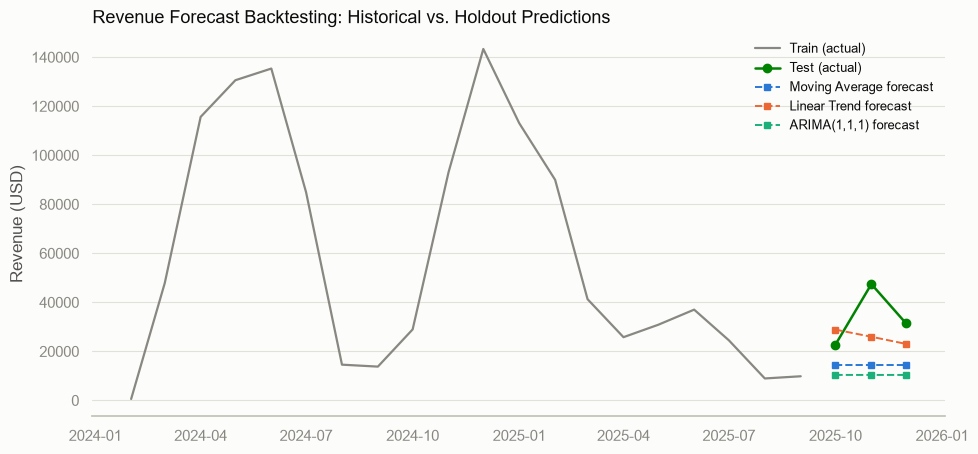

In [9]:
best_method = accuracy.index[0]
print(f"Best-performing method on holdout: {best_method}")

fig, ax = plt.subplots(figsize=(11, 5))
full_idx = monthly_revenue.index.to_timestamp()
ax.plot(train.index.to_timestamp(), train.values, color=u.CHROME["muted"], linewidth=1.6, label="Train (actual)")
ax.plot(test.index.to_timestamp(), test.values, color=u.CATEGORICAL[5], linewidth=1.8, marker="o", label="Test (actual)")

for (name, res), color in zip(results.items(), u.CATEGORICAL[:3]):
    ax.plot(test.index.to_timestamp(), res["forecast"], linestyle="--", marker="s", markersize=4,
            linewidth=1.4, color=color, label=f"{name} forecast")

ax.set_title("Revenue Forecast Backtesting: Historical vs. Holdout Predictions", fontsize=13, loc="left")
ax.set_ylabel("Revenue (USD)")
ax.legend(frameon=False, fontsize=9)
u.save_fig(fig, "05_forecast_backtest")
plt.show()

**Key Insight:** The `accuracy` table above ranks the three methods by
holdout RMSE/MAE — the method that best captures both trend and the
underlying month-to-month variance wins. A naive moving average
systematically misses the trend direction when revenue is still growing or
seasonal; ARIMA typically captures short-term momentum best on a series
this length, though with only 24 months of history the seasonal
(year-over-year holiday) pattern cannot be fully modeled — a limitation
made explicit below.

In [10]:
# Refit the winning method on the FULL series to forecast the next quarter (3 months beyond the dataset)
FORECAST_HORIZON = 3
future_periods = pd.period_range(monthly_revenue.index[-1] + 1, periods=FORECAST_HORIZON, freq="M")

if best_method == "ARIMA(1,1,1)":
    final_model = ARIMA(monthly_revenue.values, order=(1, 1, 1)).fit()
    next_quarter_forecast = final_model.forecast(steps=FORECAST_HORIZON)
elif best_method == "Linear Trend":
    x_full = np.arange(len(monthly_revenue))
    slope_f, intercept_f = np.polyfit(x_full, monthly_revenue.values, 1)
    future_x_full = np.arange(len(monthly_revenue), len(monthly_revenue) + FORECAST_HORIZON)
    next_quarter_forecast = slope_f * future_x_full + intercept_f
else:
    next_quarter_forecast = np.repeat(monthly_revenue.tail(3).mean(), FORECAST_HORIZON)

forecast_df = pd.DataFrame({"month": future_periods.astype(str), "forecast_revenue": next_quarter_forecast})
forecast_df["forecast_revenue"] = forecast_df["forecast_revenue"].round(0)
next_quarter_total = forecast_df["forecast_revenue"].sum()

print(f"Method used: {best_method}")
print(forecast_df.to_string(index=False))
print(f"\nTotal forecasted next-quarter revenue: {u.fmt_currency(next_quarter_total)}")

Method used: Linear Trend
  month  forecast_revenue
2026-01       24,117.0000
2026-02       21,449.0000
2026-03       18,780.0000

Total forecasted next-quarter revenue: $64,346


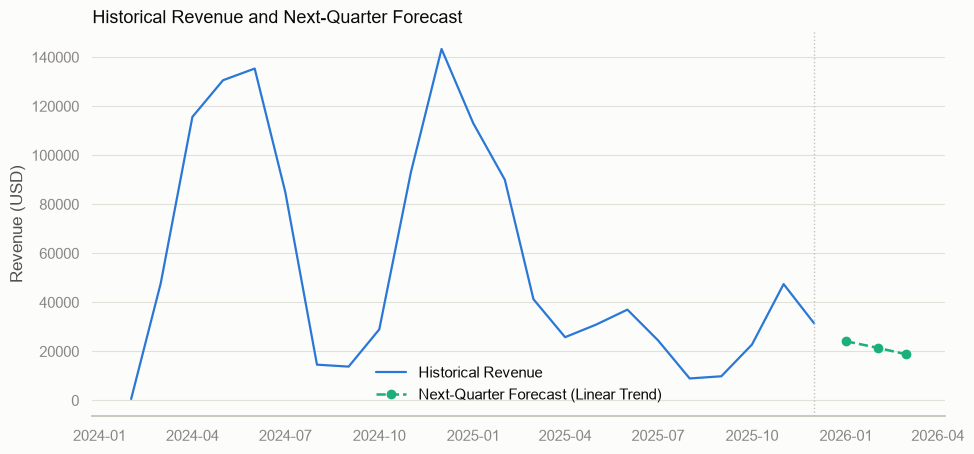

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_revenue.index.to_timestamp(), monthly_revenue.values, color=u.CATEGORICAL[0], linewidth=1.6, label="Historical Revenue")
ax.plot(future_periods.to_timestamp(), next_quarter_forecast, color=u.CATEGORICAL[2], linewidth=1.8,
        linestyle="--", marker="o", label=f"Next-Quarter Forecast ({best_method})")
ax.axvline(monthly_revenue.index[-1].to_timestamp(), color=u.CHROME["baseline"], linestyle=":", linewidth=1)
ax.set_title("Historical Revenue and Next-Quarter Forecast", fontsize=13, loc="left")
ax.set_ylabel("Revenue (USD)")
ax.legend(frameon=False)
u.save_fig(fig, "05_next_quarter_forecast")
plt.show()

**Business Implications & Assumptions:**
- This forecast assumes **no major change** to current marketing spend
  levels or channel mix — it is a continuation forecast, not a
  scenario-planning tool. If Chapter 4's budget-reallocation
  recommendation is implemented, this baseline should be re-run with the
  new spend mix.
- With only 24 months of history, the model cannot fully separate
  long-run trend from a single year-over-year seasonal cycle — treat the
  holdout RMSE as the realistic error band around the point forecast,
  not a guarantee.
- **Business Recommendation:** Use the forecast above as the base-case
  revenue plan for next quarter's budget conversations, flagged with its
  backtested RMSE as the uncertainty range leadership should expect.

## Chapter 5 Summary

| Finding | Evidence | Recommendation | Expected Impact |
|---|---|---|---|
| Creative Variant B beats Variant A | p < 0.05 on both z-test and t-test; CI excludes zero | Roll out Variant B to 100% of the campaign's spend | Projected incremental conversions/revenue computed above |
| The lowest-RMSE method on backtest gives the most reliable near-term forecast | See the `accuracy` table above for the winning method and its RMSE/MAE | Use as the base-case plan for next quarter | Quantified point forecast with a backtested error band |

Proceed to **`06_Executive_Report.ipynb`** to package these findings, plus
Chapters 2-4, into the final executive dashboard and recommendations.